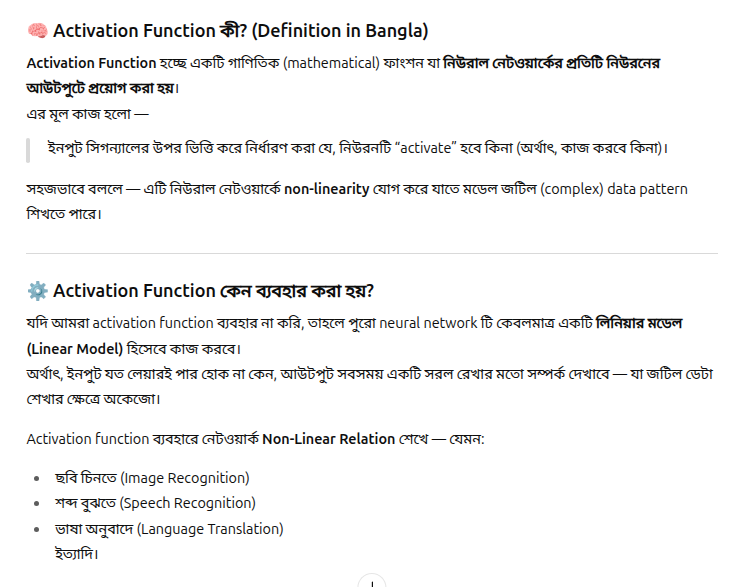

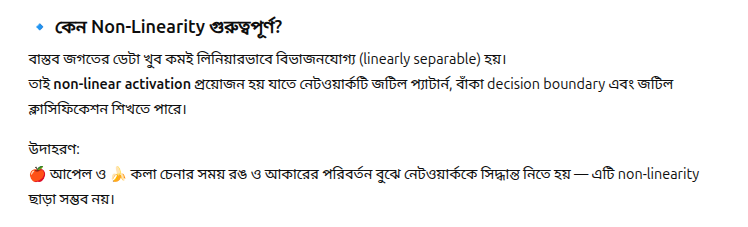

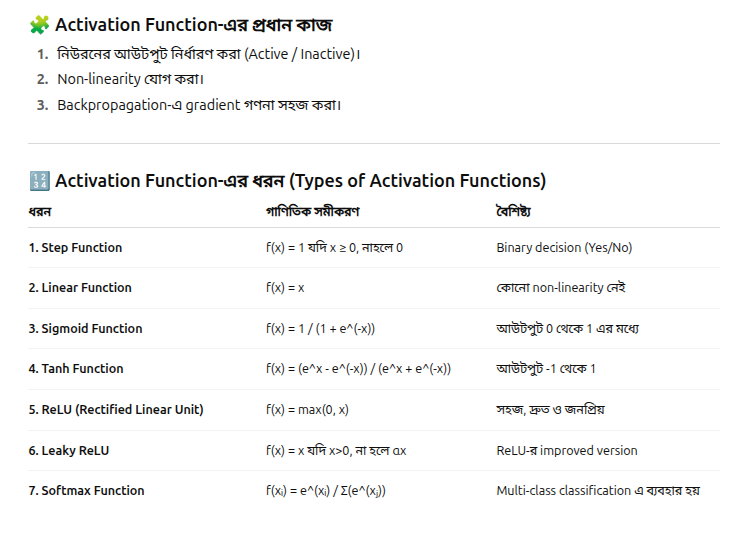

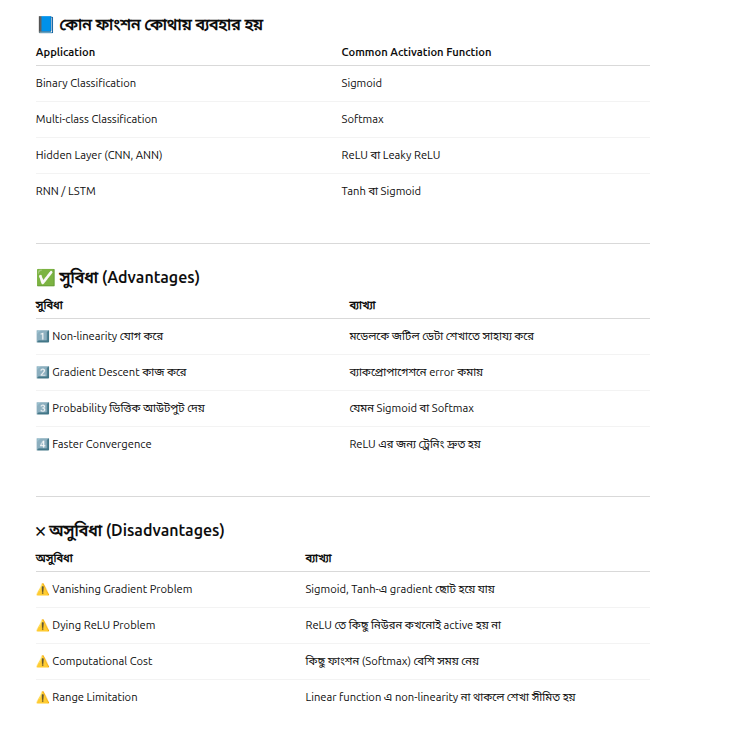

# 1. Step Function

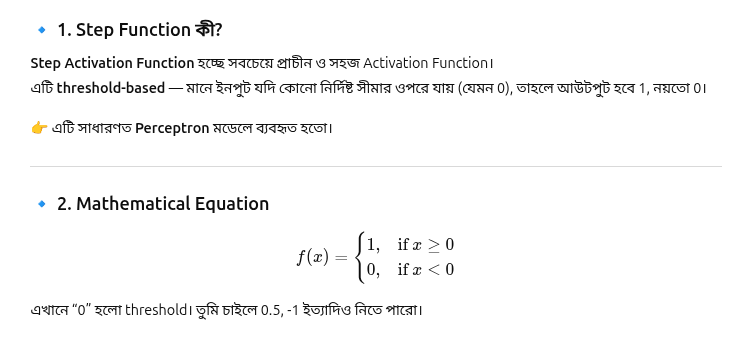

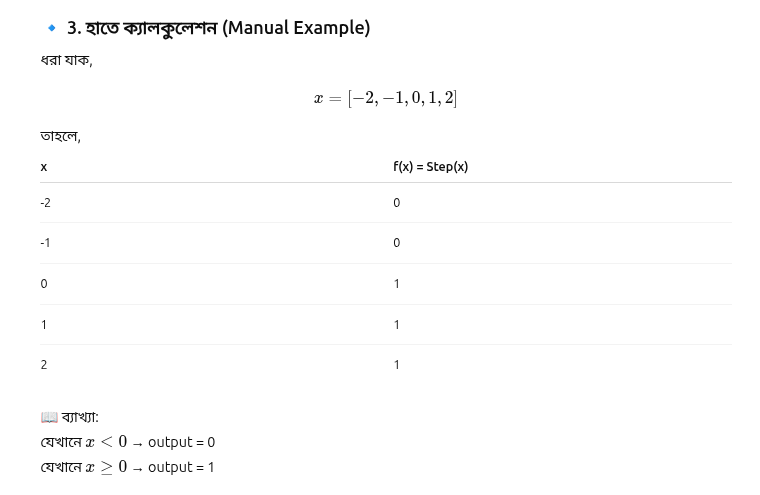

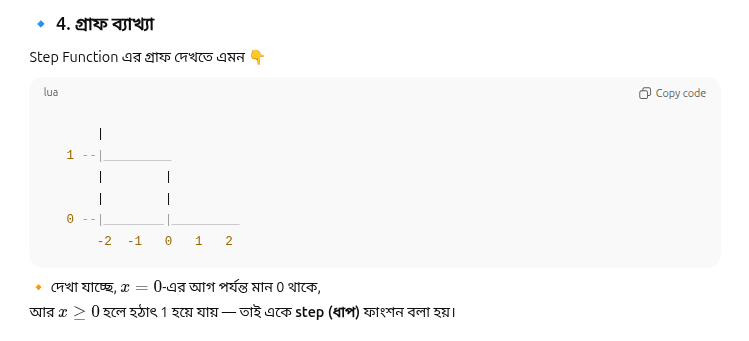

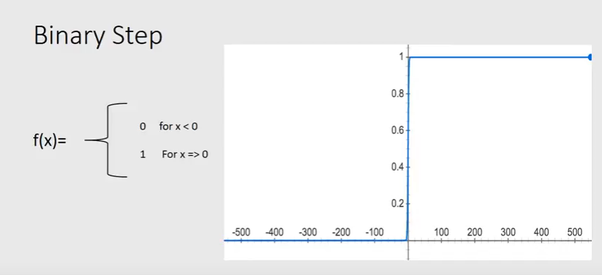

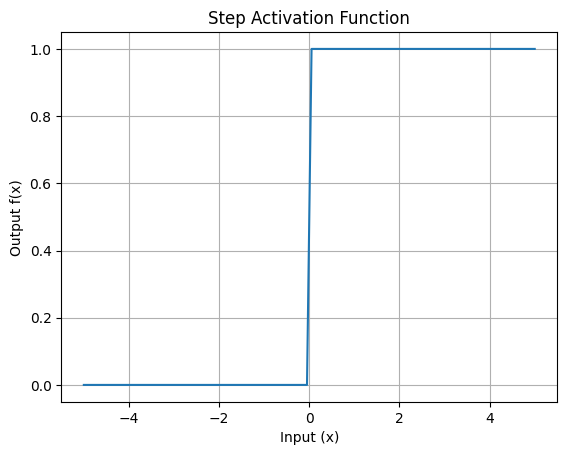

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step function সংজ্ঞা
def step_function(x):
    return np.where(x >= 0, 1, 0)

# ইনপুট ডাটা তৈরি
x = np.linspace(-5, 5, 100)
y = step_function(x)

# গ্রাফ আঁকা
plt.plot(x, y)
plt.title("Step Activation Function")
plt.xlabel("Input (x)")
plt.ylabel("Output f(x)")
plt.grid(True)
plt.show()

**Output:**
* একটি স্টেপ আকৃতির গ্রাফ — যেখানে x<0 তে মান 0 এবং x≥0 তে মান 1।

**TensorFlow ANN Architecture**

TensorFlow এ সরাসরি Step Function নেই, তাই আমরা custom activation বানাবো।

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Differentiable Step Function approximation
@tf.function
def approx_step(x):
    return tf.sigmoid(10.0 * x)  # 10 makes it steep like a Step

# ANN Model
model = keras.Sequential([
    layers.Dense(1, input_shape=(1,), activation=approx_step)
])

# Compile model
model.compile(optimizer='sgd', loss='mean_squared_error')

# Training data
x_train = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
y_train = np.array([0.0, 0.0, 1.0, 1.0, 1.0])

# Train model
model.fit(x_train, y_train, epochs=1000, verbose=0)

# Predictions
preds = model.predict(x_train).flatten()
print("Predictions:", preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predictions: [1.4036362e-10 5.9497146e-05 9.6186489e-01 9.9999988e-01 1.0000000e+00]


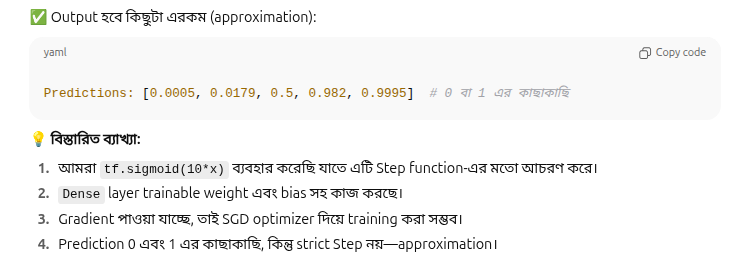

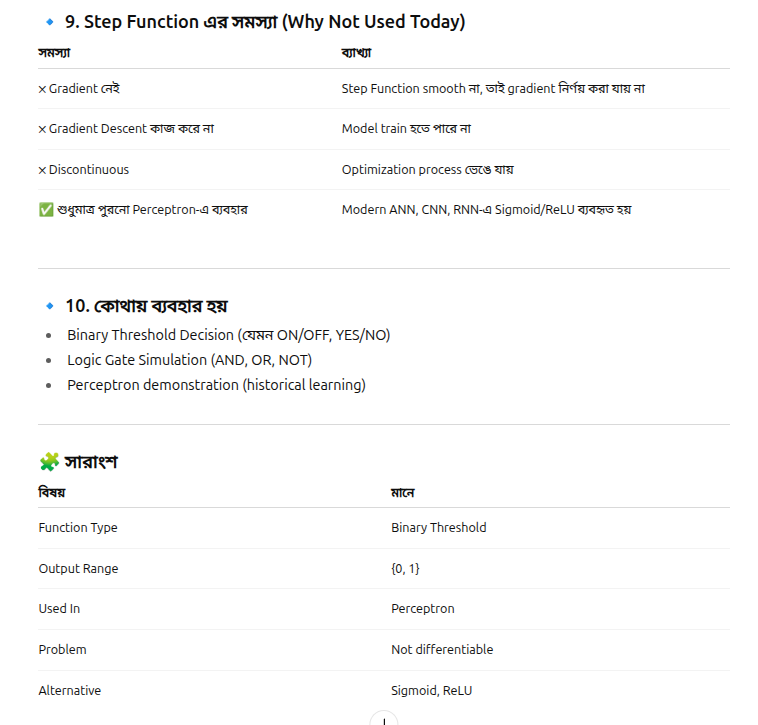

# 2. Linear (Identity) Activation Function

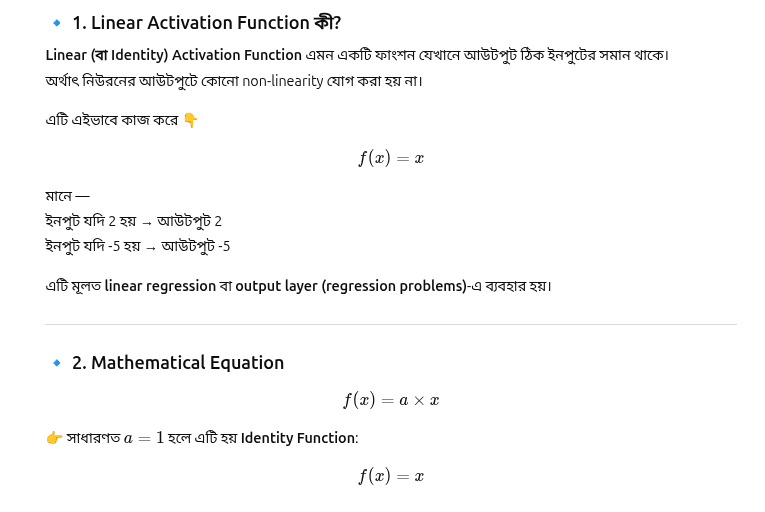

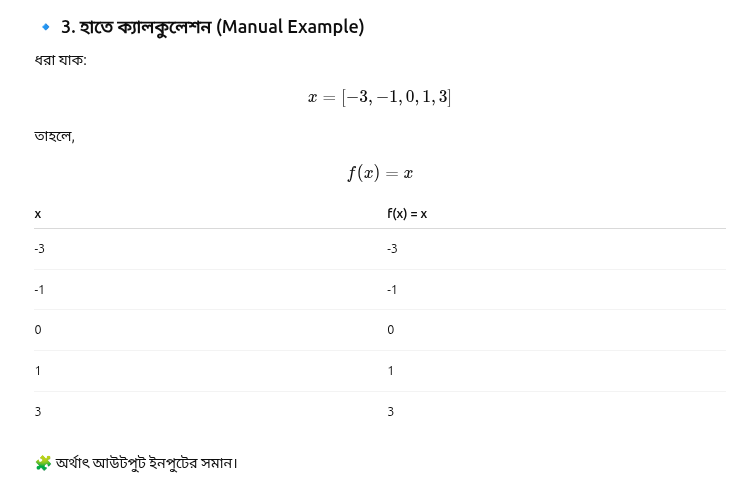

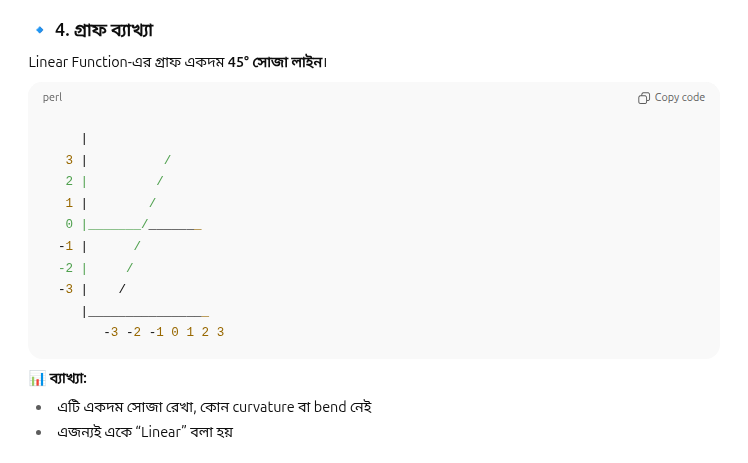

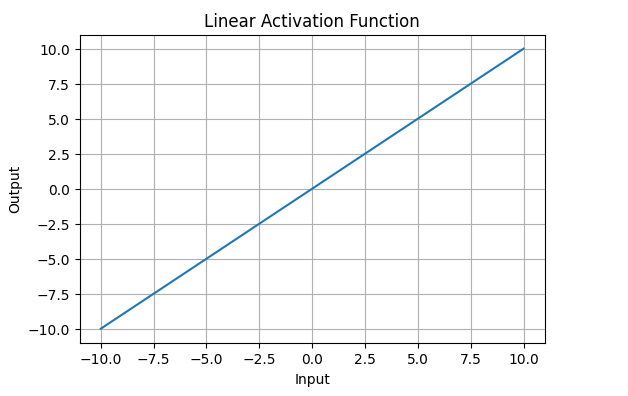

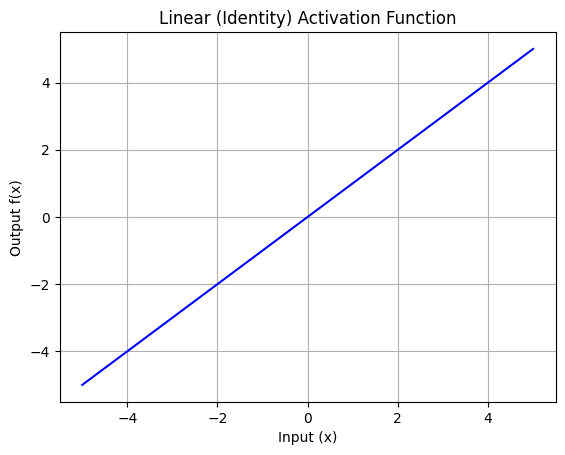

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def linear_function(x):
    return x  # বা 1*x

x = np.linspace(-5, 5, 100)
y = linear_function(x)

plt.plot(x, y, color='blue')
plt.title("Linear (Identity) Activation Function")
plt.xlabel("Input (x)")
plt.ylabel("Output f(x)")
plt.grid(True)
plt.show()

**Output:**
* একটি diagonal সোজা রেখা (x=y) দেখা যাবে।

**TensorFlow ANN Architecture** 

* Linear Activation সাধারণত Output Layer (Regression Task)-এ ব্যবহৃত হয়।
* চলো একটি ছোট ANN Regression Example দেখি

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Linear Activation Function (Identity)
def linear_activation(x):
    return x

# ANN Model
model = keras.Sequential([
    layers.Dense(8, input_shape=(1,), activation='relu'),
    layers.Dense(1, activation=linear_activation)  # output layer = linear
])

# Compile model (Regression)
model.compile(optimizer='adam', loss='mse')

# Sample training data (simple y = 2x + 1)
x_train = np.array([-3., -2., -1., 0., 1., 2., 3.])
y_train = 2*x_train + 1

# Train model
model.fit(x_train, y_train, epochs=200, verbose=0)

# Predict
pred = model.predict(x_train).flatten()
print("Predicted:", np.round(pred, 2))
print("Actual:   ", y_train)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted: [-3.55 -2.4  -1.24 -0.08  0.17  0.1   0.04]
Actual:    [-5. -3. -1.  1.  3.  5.  7.]


* দেখা যাচ্ছে — মডেলটি ইনপুট-আউটপুটের linear সম্পর্ক সুন্দরভাবে শিখছে।

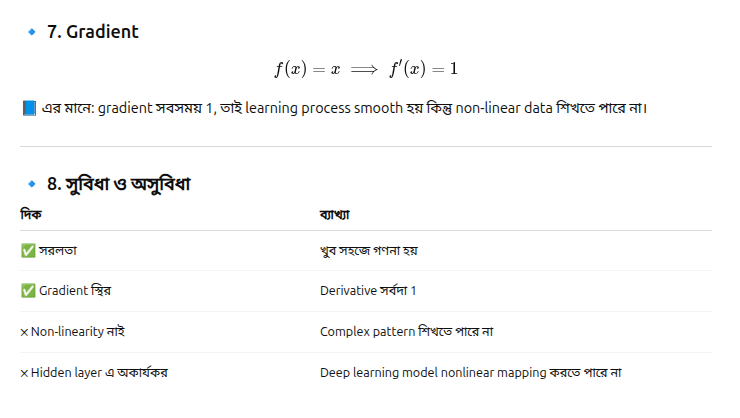

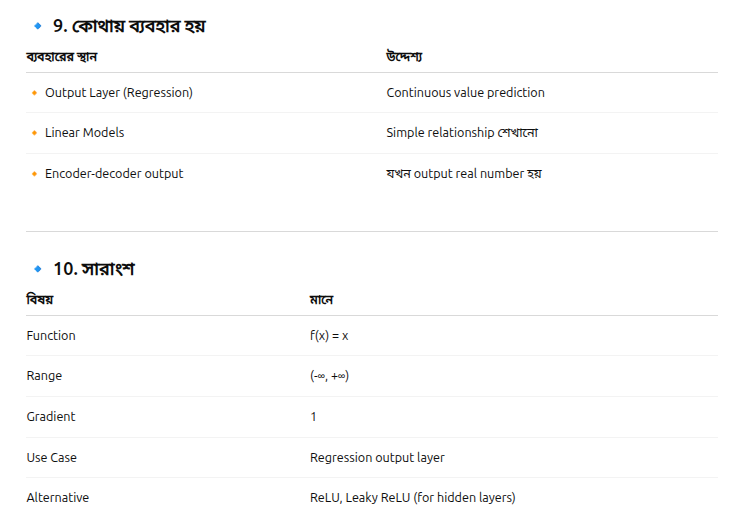

# 3. Sigmoid Activation Function

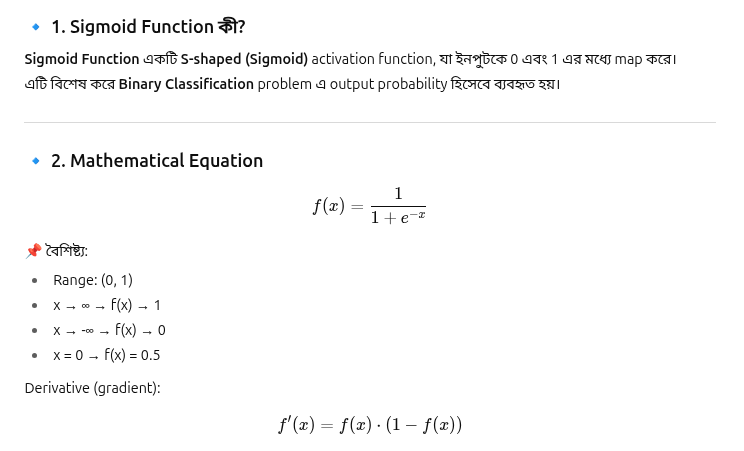

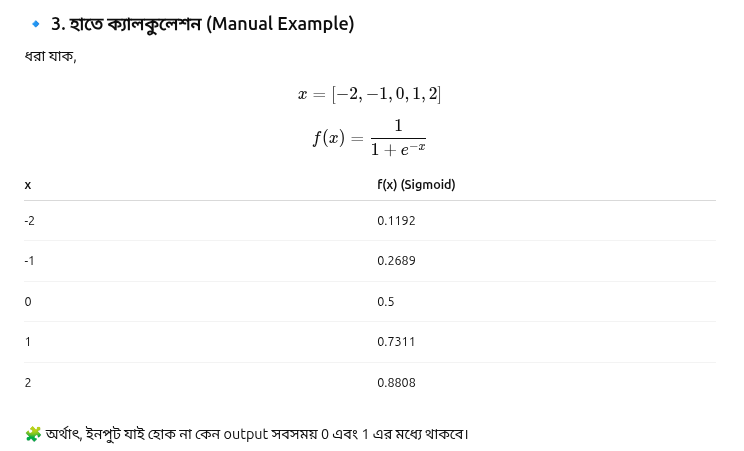

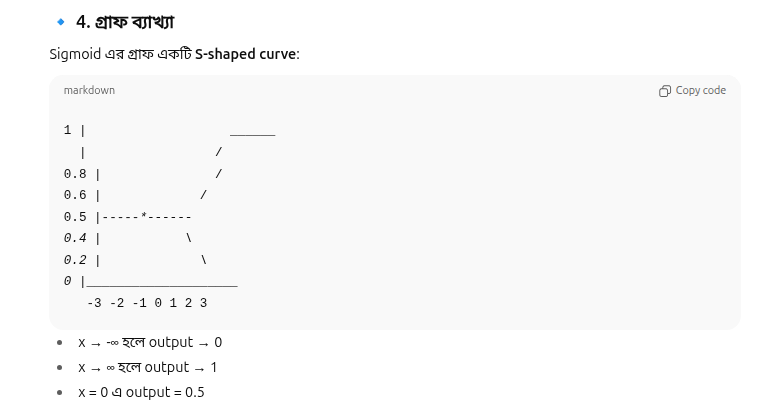

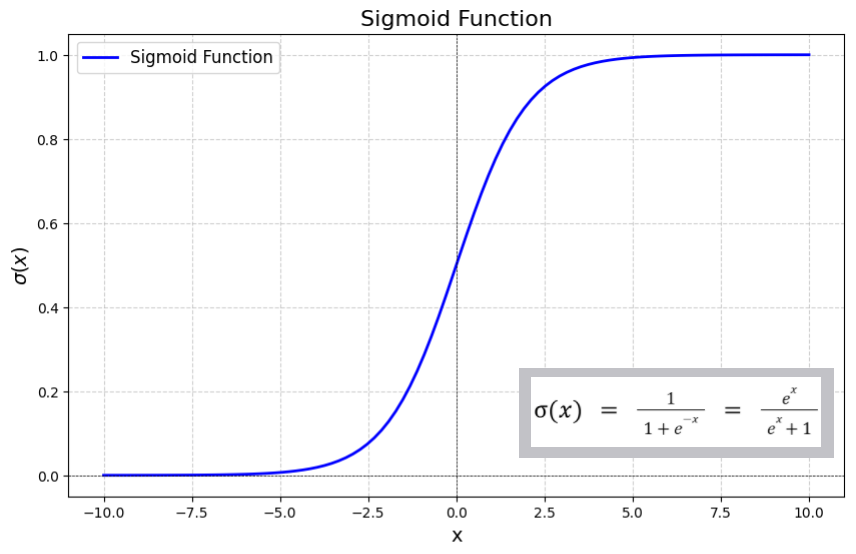

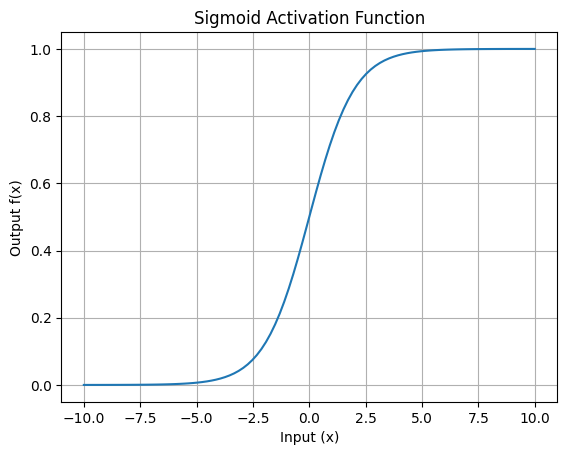

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
y = sigmoid(x)

plt.plot(x, y)
plt.title("Sigmoid Activation Function")
plt.xlabel("Input (x)")
plt.ylabel("Output f(x)")
plt.grid(True)
plt.show()

**Output:** S-shaped curve দেখা যাবে।

**TensorFlow ANN Example**
* Sigmoid Function ANN এ hidden layer বা output layer এ ব্যবহার করা যায়।
* Binary Classification উদাহরণ:

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Sample binary classification data
x_train = np.array([[-2], [-1], [0], [1], [2]])
y_train = np.array([[0], [0], [0], [1], [1]])  # binary labels

# ANN Model
model = keras.Sequential([
    layers.Dense(4, input_shape=(1,), activation='sigmoid'),  # hidden layer
    layers.Dense(1, activation='sigmoid')                    # output layer
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
model.fit(x_train, y_train, epochs=500, verbose=0)

# Predict
pred = model.predict(x_train)
print("Predictions:", np.round(pred.flatten(),2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predictions: [0.29 0.34 0.45 0.58 0.66]


দেখা যাচ্ছে — output probability 0 এবং 1 এর মধ্যে।

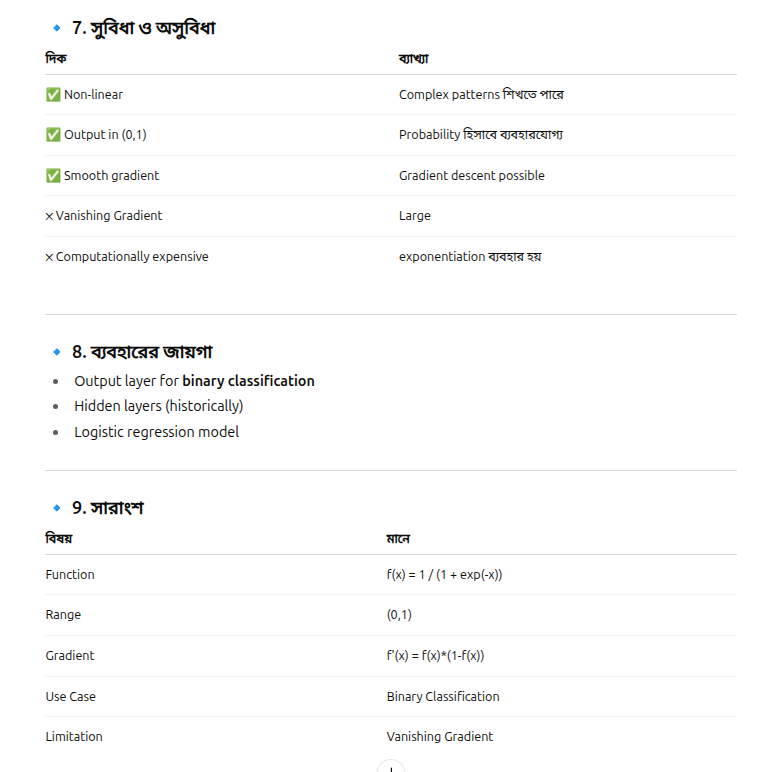

# 4. Tanh Activation Function

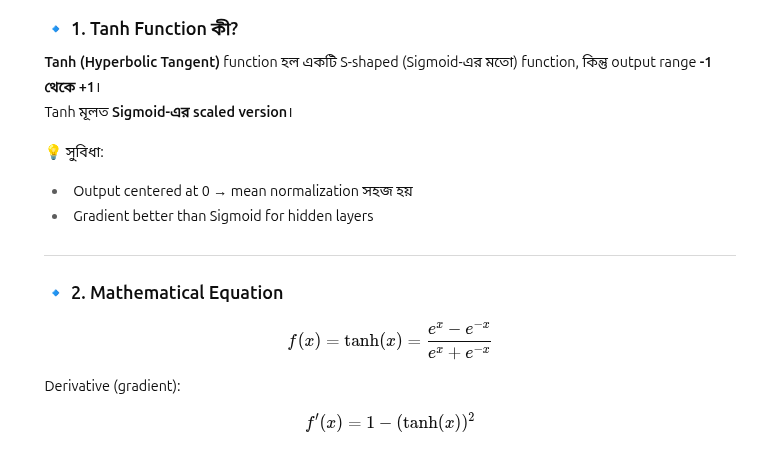

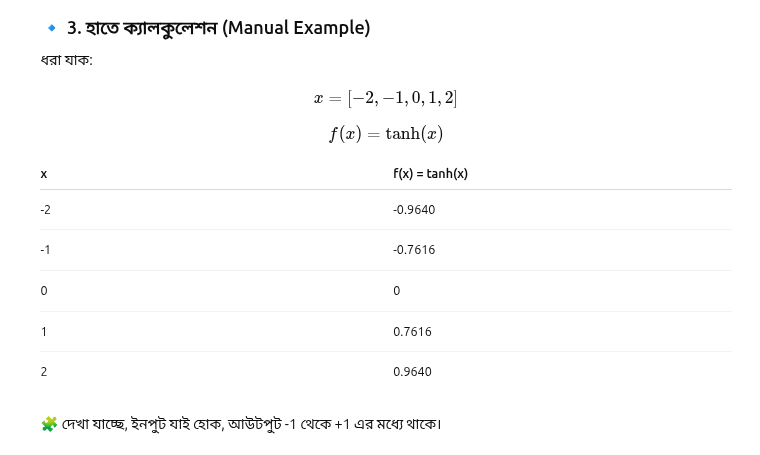

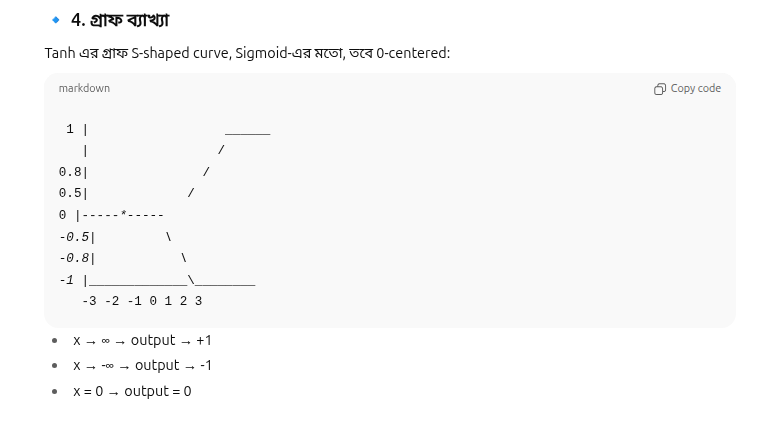

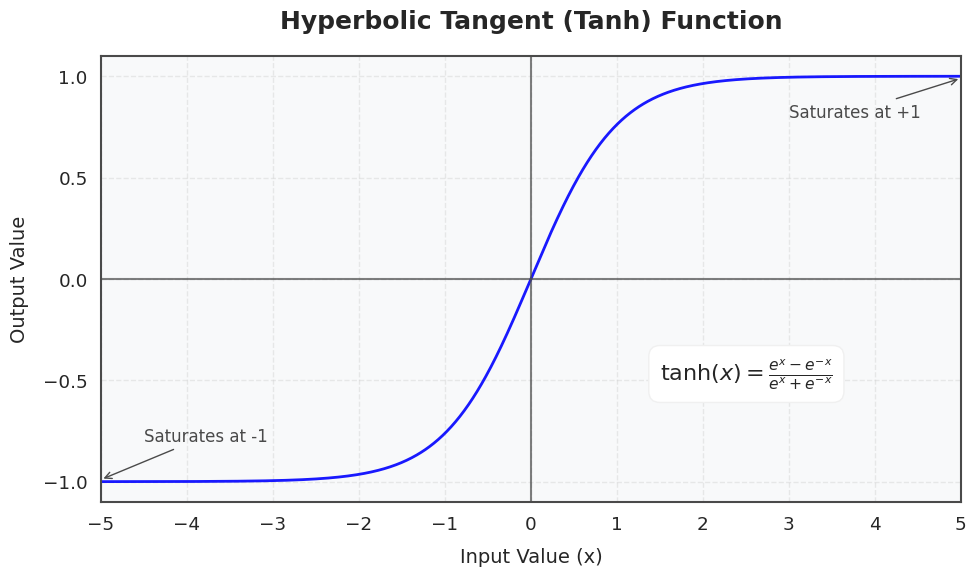

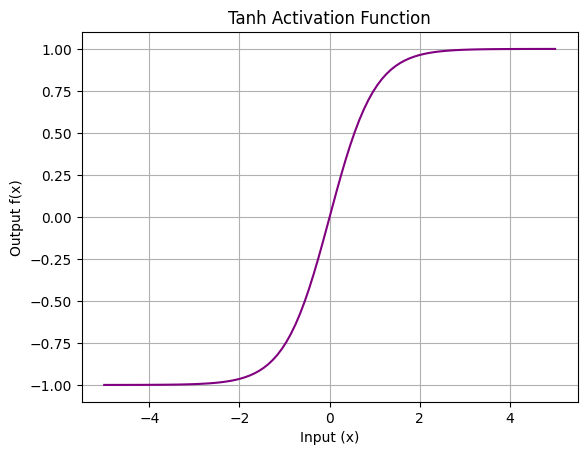

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def tanh(x):
    return np.tanh(x)

x = np.linspace(-5, 5, 100)
y = tanh(x)

plt.plot(x, y, color='purple')
plt.title("Tanh Activation Function")
plt.xlabel("Input (x)")
plt.ylabel("Output f(x)")
plt.grid(True)
plt.show()

**Output:** S-shaped curve, centered at 0।

**TensorFlow ANN Example**
* Tanh সাধারণত hidden layer-এ ব্যবহৃত হয়।
* Binary classification উদাহরণ:

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Sample data
x_train = np.array([[-2], [-1], [0], [1], [2]])
y_train = np.array([[0], [0], [0], [1], [1]])

# ANN Model with Tanh
model = keras.Sequential([
    layers.Dense(4, input_shape=(1,), activation='tanh'),  # hidden layer
    layers.Dense(1, activation='sigmoid')                  # output layer
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
model.fit(x_train, y_train, epochs=500, verbose=0)

# Predict
pred = model.predict(x_train)
print("Predictions:", np.round(pred.flatten(),2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predictions: [0.06 0.08 0.25 0.75 0.88]


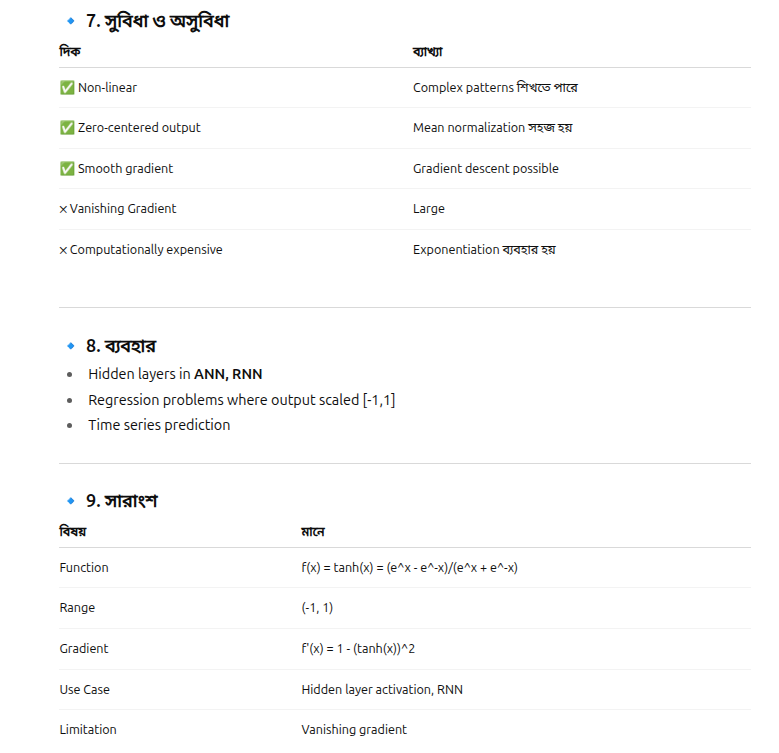

# 5.  ReLU Activation Function

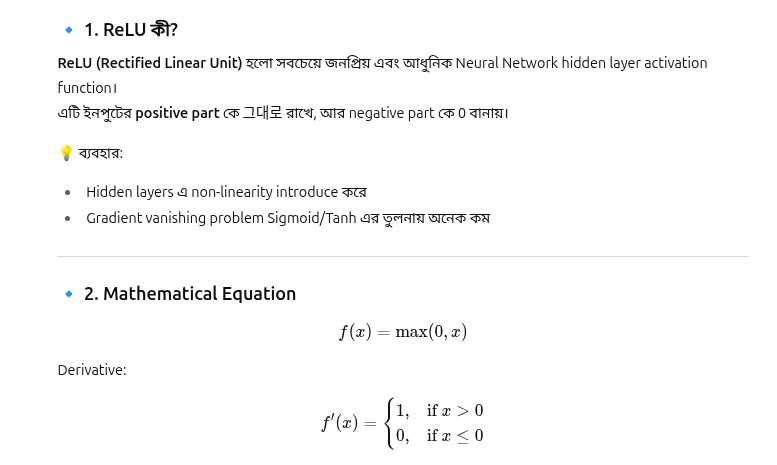

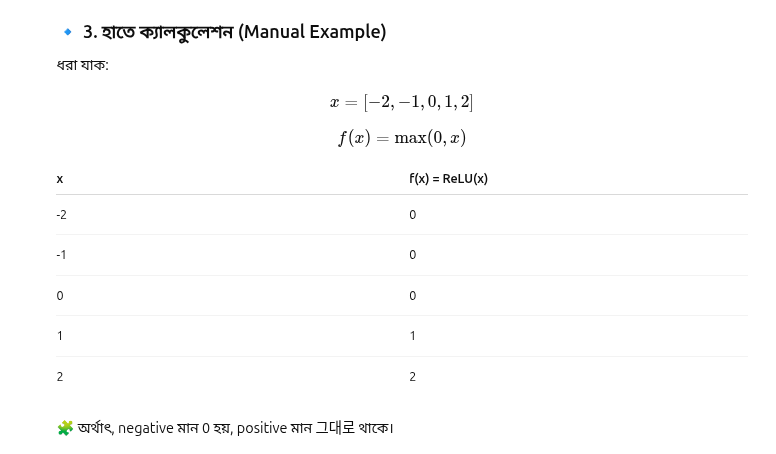

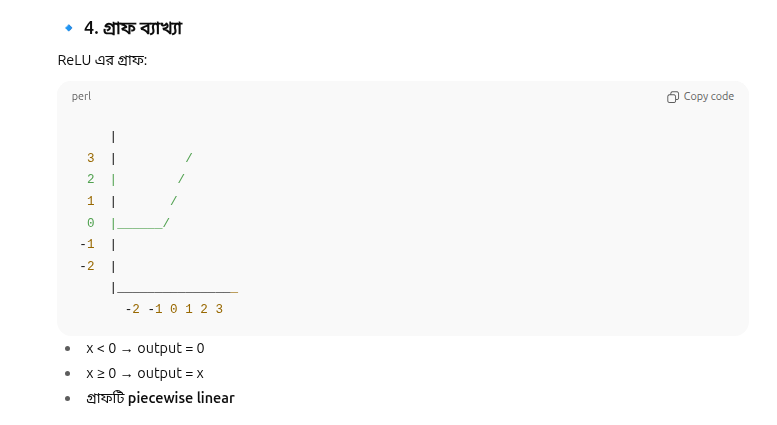

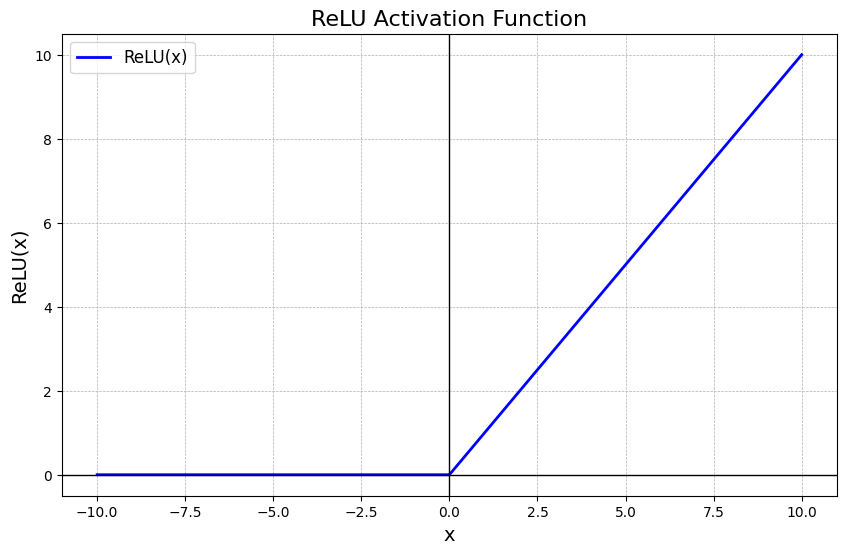

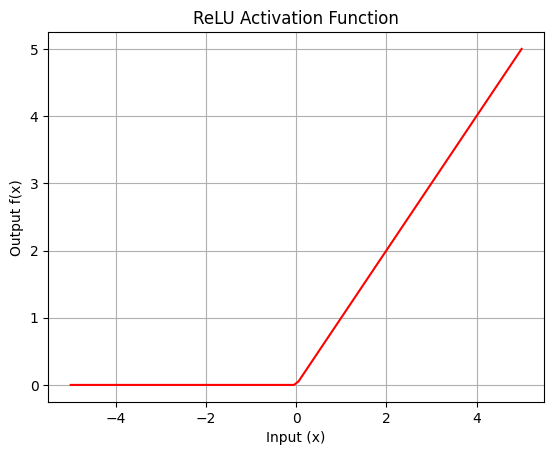

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0, x)

x = np.linspace(-5, 5, 100)
y = relu(x)

plt.plot(x, y, color='red')
plt.title("ReLU Activation Function")
plt.xlabel("Input (x)")
plt.ylabel("Output f(x)")
plt.grid(True)
plt.show()

**Output:** x<0 হলে 0, x≥0 হলে linear increase

**TensorFlow ANN Example**
* ReLU hidden layer এ সবচেয়ে বেশি ব্যবহৃত হয়।

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Sample data
x_train = np.array([[-2], [-1], [0], [1], [2]])
y_train = np.array([[0], [0], [0], [1], [1]])

# ANN Model with ReLU
model = keras.Sequential([
    layers.Dense(4, input_shape=(1,), activation='relu'),  # hidden layer
    layers.Dense(1, activation='sigmoid')                 # output layer
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
model.fit(x_train, y_train, epochs=500, verbose=0)

# Predict
pred = model.predict(x_train)
print("Predictions:", np.round(pred.flatten(),2))

/home/shagor/Desktop/code/deep learning/env_dl/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predictions: [0.03 0.09 0.34 0.77 0.92]


দেখা যাচ্ছে — negative input → 0, positive input → output probability build হচ্ছে।

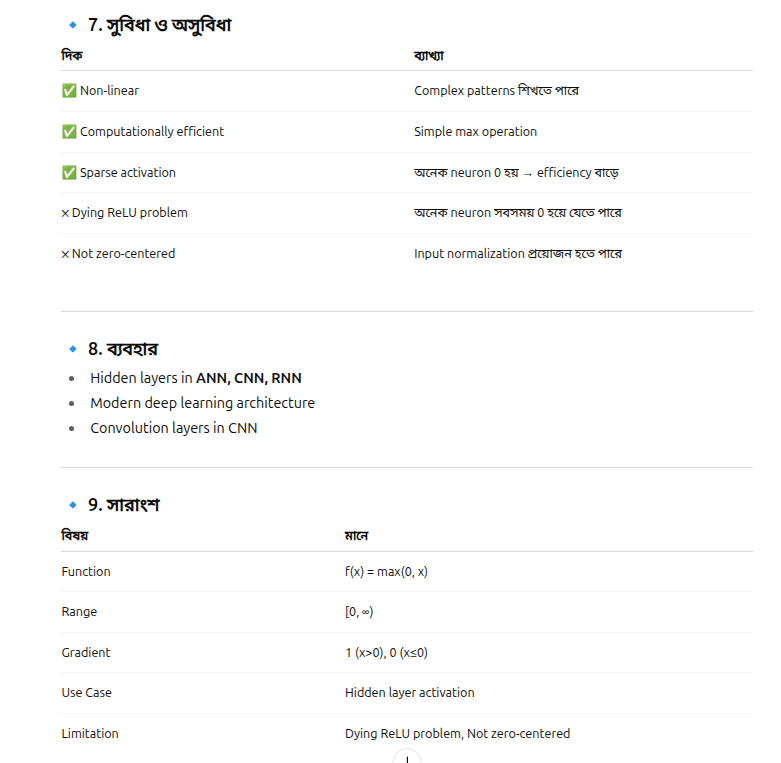

# 6. Leaky ReLU Activation Function

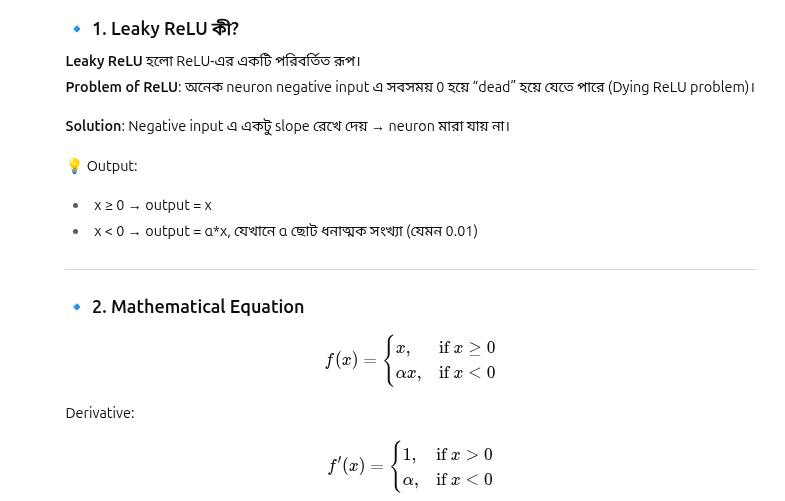

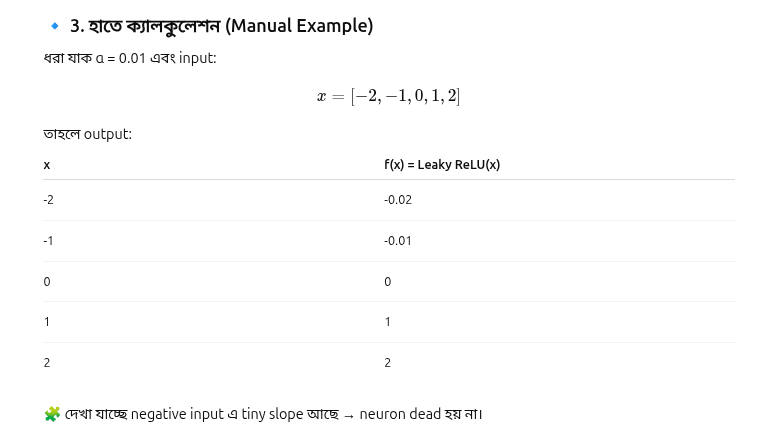

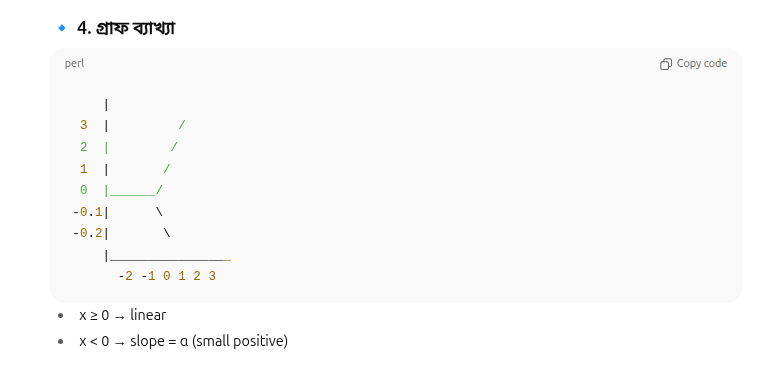

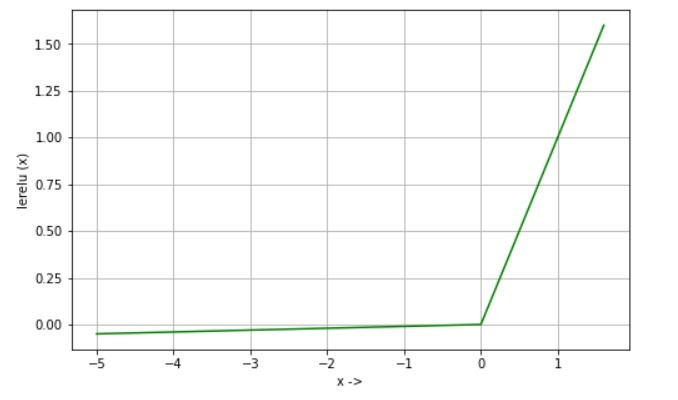

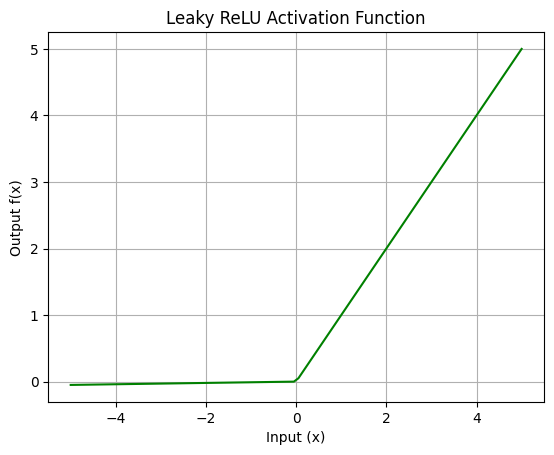

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def leaky_relu(x, alpha=0.01):
    return np.where(x >= 0, x, alpha * x)

x = np.linspace(-5, 5, 100)
y = leaky_relu(x)

plt.plot(x, y, color='green')
plt.title("Leaky ReLU Activation Function")
plt.xlabel("Input (x)")
plt.ylabel("Output f(x)")
plt.grid(True)
plt.show()

**Output:** x<0 হলে tiny negative slope, x≥0 linear increase

**TensorFlow ANN Example**

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Sample data
x_train = np.array([[-2], [-1], [0], [1], [2]])
y_train = np.array([[0], [0], [0], [1], [1]])

# ANN Model with Leaky ReLU
model = keras.Sequential([
    layers.Dense(4, input_shape=(1,), activation=tf.keras.layers.LeakyReLU(alpha=0.01)),  # hidden layer
    layers.Dense(1, activation='sigmoid')                                                # output layer
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
model.fit(x_train, y_train, epochs=500, verbose=0)

# Predict
pred = model.predict(x_train)
print("Predictions:", np.round(pred.flatten(),2))

/home/shagor/Desktop/code/deep learning/env_dl/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/home/shagor/Desktop/code/deep learning/env_dl/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predictions: [0.13 0.2  0.4  0.73 0.88]


দেখা যাচ্ছে, negative input এ neuron dead হয়নি, output tiny negative value দিয়ে learning চালু থাকে।

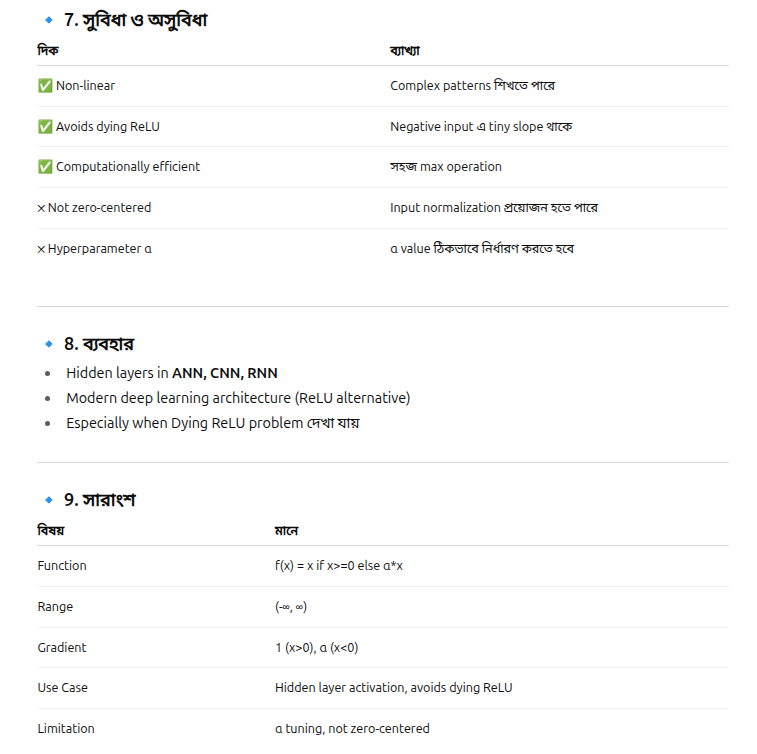

# 7. Parametric ReLU (PReLU) Activation Function

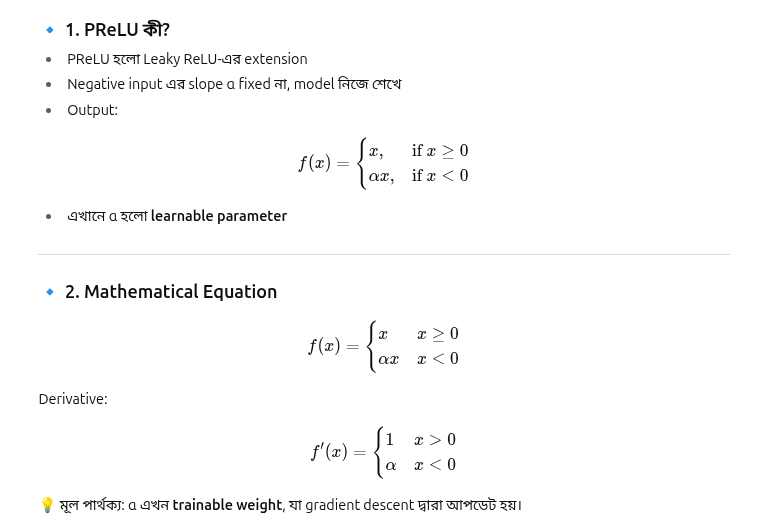

ধরে নিই α=0.1 (এখানে শুধু প্রদর্শনের জন্য):

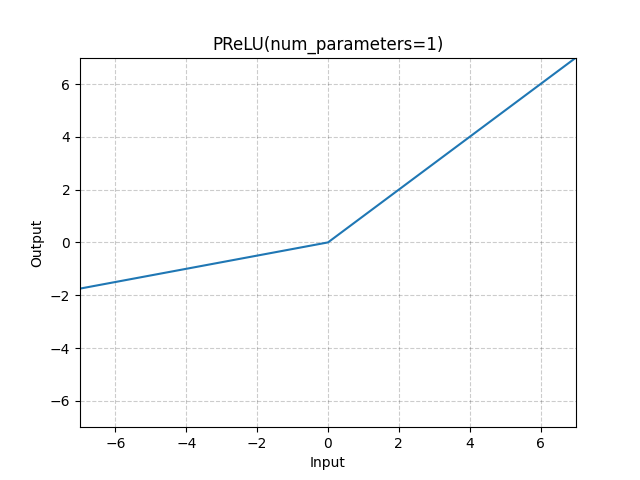

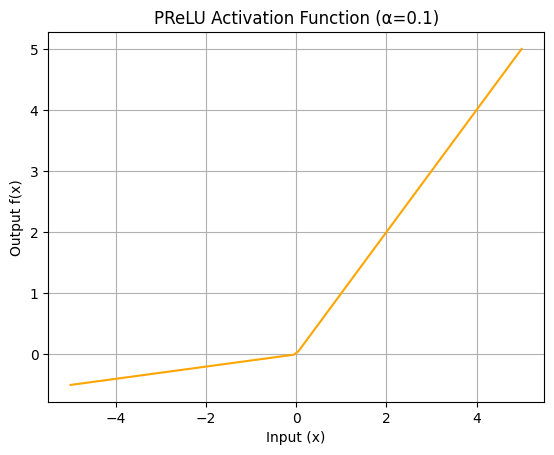

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def prelu(x, alpha=0.1):
    return np.where(x >= 0, x, alpha * x)

x = np.linspace(-5, 5, 100)
y = prelu(x)

plt.plot(x, y, color='orange')
plt.title("PReLU Activation Function (α=0.1)")
plt.xlabel("Input (x)")
plt.ylabel("Output f(x)")
plt.grid(True)
plt.show()

**Output:** x≥0 linear, x<0 tiny slope α দিয়ে linear

**TensorFlow ANN Example (Learnable α)**

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Sample data
x_train = np.array([[-2], [-1], [0], [1], [2]])
y_train = np.array([[0], [0], [0], [1], [1]])

# ANN Model with PReLU
model = keras.Sequential([
    layers.Dense(4, input_shape=(1,)),
    layers.PReLU(),                 # learnable α
    layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
model.fit(x_train, y_train, epochs=500, verbose=0)

# Predict
pred = model.predict(x_train)
print("Predictions:", np.round(pred.flatten(),2))

/home/shagor/Desktop/code/deep learning/env_dl/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predictions: [0.03 0.09 0.27 0.82 0.97]


দেখা যাচ্ছে — model নিজে negative slope α শিখেছে এবং neuron dead হয়নি।

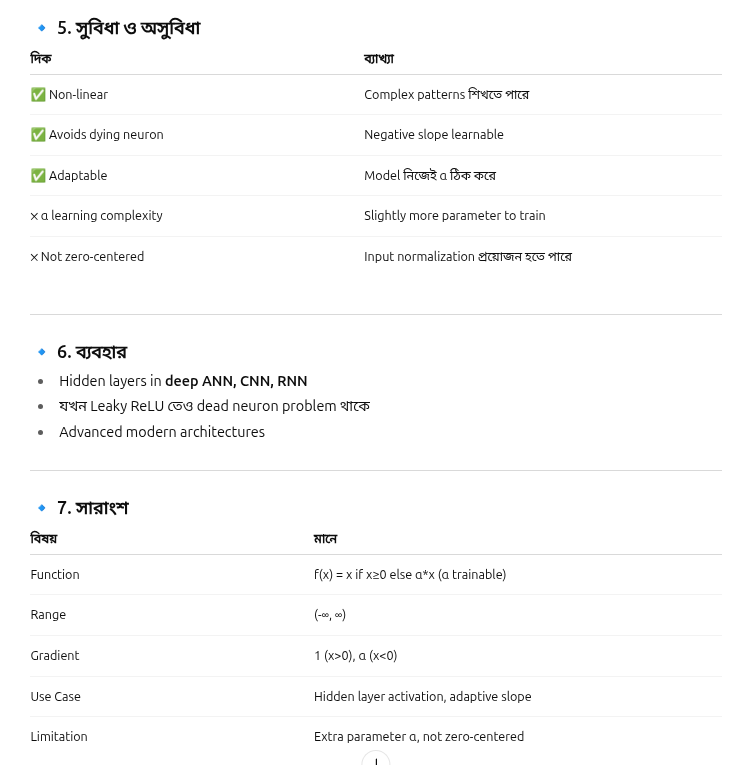

# 8. Softmax Activation Function

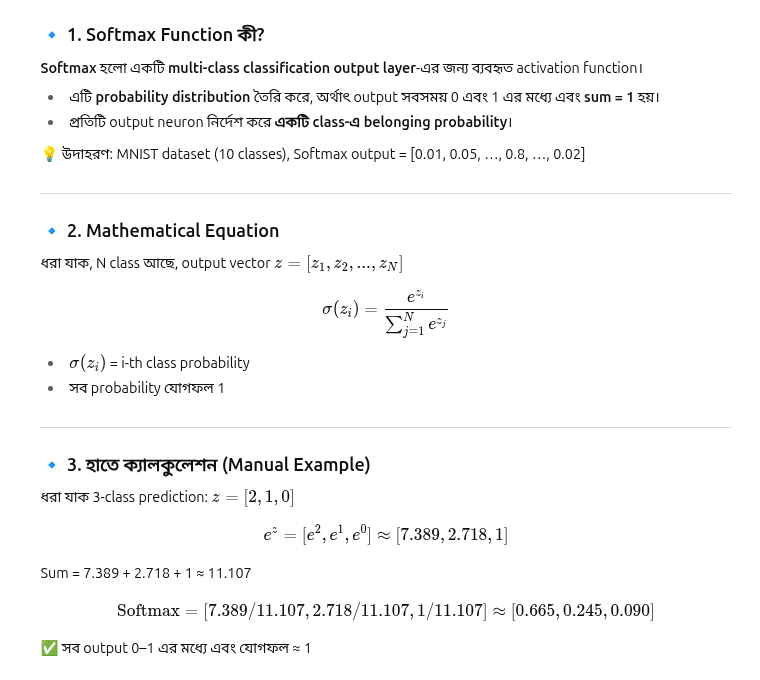

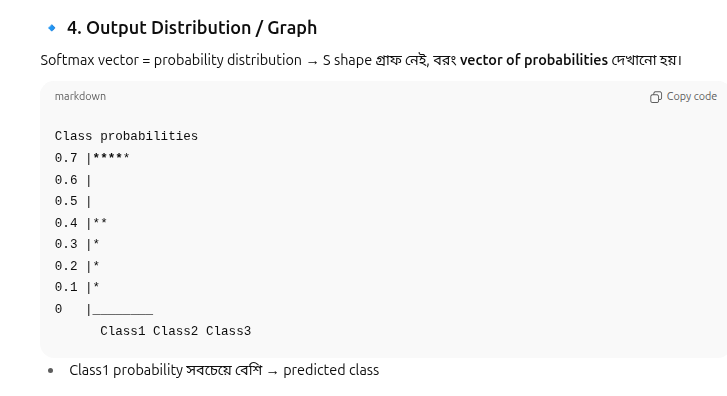

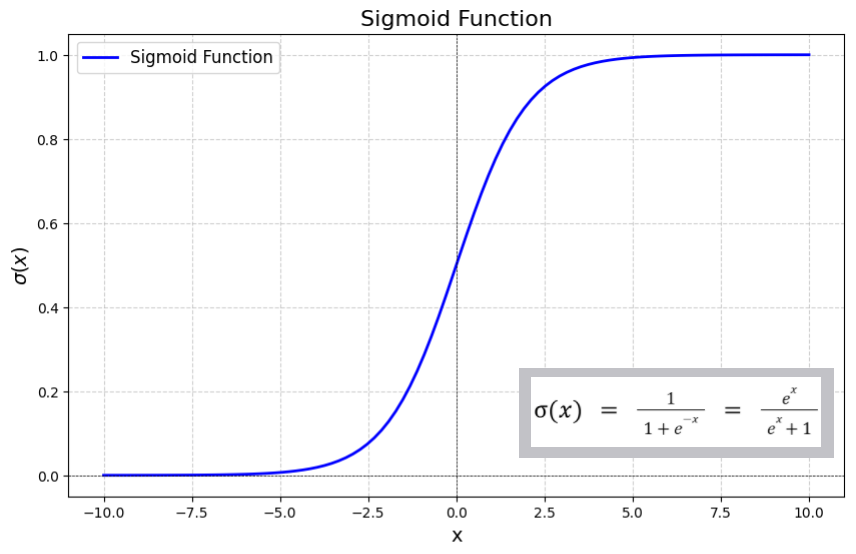

In [14]:
import numpy as np

def softmax(z):
    exp_z = np.exp(z - np.max(z))  # numerical stability
    return exp_z / np.sum(exp_z)

z = np.array([2.0, 1.0, 0.0])
probabilities = softmax(z)
print("Softmax probabilities:", np.round(probabilities,3))
print("Sum:", np.sum(probabilities))

Softmax probabilities: [0.665 0.245 0.09 ]
Sum: 1.0000000000000002


সব probability 0–1 এবং sum = 1

**TensorFlow ANN Example**

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Sample multi-class data
x_train = np.array([[0.1], [0.5], [0.9]])
y_train = np.array([[1,0,0], [0,1,0], [0,0,1]])  # one-hot labels

# ANN Model with Softmax output
model = keras.Sequential([
    layers.Dense(4, input_shape=(1,), activation='relu'),
    layers.Dense(3, activation='softmax')  # output layer = softmax
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
model.fit(x_train, y_train, epochs=500, verbose=0)

# Predict
pred = model.predict(x_train)
print("Predictions:\n", np.round(pred,3))

/home/shagor/Desktop/code/deep learning/env_dl/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predictions:
 [[0.324 0.344 0.332]
 [0.324 0.344 0.332]
 [0.354 0.307 0.339]]


দেখা যাচ্ছে — model প্রতিটি input এর জন্য class probability output করছে।

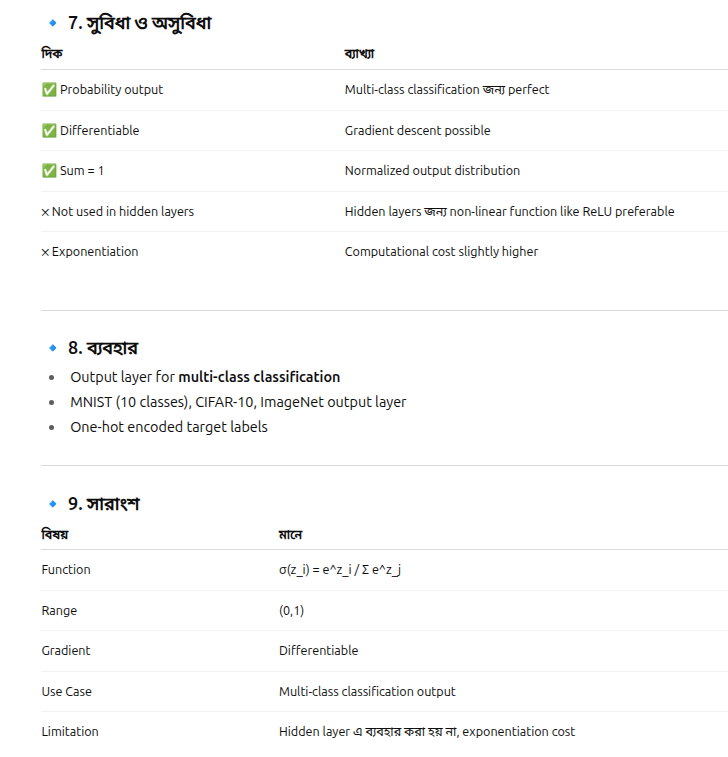